In [ ]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy


sys.path.append('..')
import plot_settings
plot_settings.apply()
colors = plot_settings.colors()

# Importing data

In [ ]:
DT = 2
Q0 = 17921.57581 
#(data['I'][data['trajectory'] == 10].values)[0]  * 3600 / (data['C'][data['trajectory'] == 10].values)[0]  
#print(f'Q0: {Q0:.5f} As')

In [ ]:

def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data_bin/{file_name}.txt",
        delim_whitespace=True,
        comment="%",
        header=None
    )

    df.columns = ['u_par','C','t','E_cell (V)','I_cell (A)','Rx_cell (N)','u_cell (m)','E_ocv_cell (V)']

    # Sort by time within each batch
    return df



path = f'test_data_50beta_20p'

data = read_data(path)

#rename columns
data.columns = ['u_par','C','t','V_t','I','Rx','u','ocv']

data['u'] = data['u'] * -1e5
data['Rx'] = data['Rx'] * -1e-9
data['I'] = data['I'] * -1.
data['eta'] = data['V_t'] - data['ocv']


/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_88360/2799590422.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


To deal with more reasonable values, $F$ is measured in GN, while $\Delta u$ is measured in $10^{-5}$ m

In [ ]:
# Add numeric trajectory id for each unique (C, u_par) pair
data['trajectory'] = data.groupby(['C', 'u_par'], sort=False).ngroup()

# Optional lookup table (one row per trajectory)
trajectory_lookup = (
    data[['C', 'u_par', 'trajectory']]
    .drop_duplicates()
    .sort_values('trajectory')
    .reset_index(drop=True)
)

print(trajectory_lookup)
print(f"Number of trajectories: {trajectory_lookup['trajectory'].nunique()}")

      C  u_par  trajectory
0   2.8    0.6           0
1   0.8    2.2           1
2   2.3   24.2           2
3   1.8   25.8           3
4   2.0   15.5           4
5   4.3   29.7           5
6   3.2   17.7           6
7   4.9    7.8           7
8   1.1   27.0           8
9   3.7   19.2           9
10  4.7    3.3          10
11  3.3    4.7          11
12  2.3   11.2          12
13  1.4   10.0          13
14  0.7   13.2          14
15  3.9   21.4          15
16  4.2   23.5          16
17  3.6    6.7          17
18  2.6   14.6          18
19  1.3   20.1          19
Number of trajectories: 20


In [ ]:
# Add finite-difference columns with the same length as `data`
dV = np.diff(data['V_t'].to_numpy())[:-1] / DT
dRx = np.diff(data['Rx'].to_numpy())[:-1] / DT

if len(dV) > 0:
    for i in range(2):
        dV = np.append(dV, dV[-1])
        dRx = np.append(dRx, dRx[-1])
else:
    dV = np.array([0.0])
    dRx = np.array([0.0])

data['dV_t'] = dV
data['dRx'] = dRx

data.head()


,u_par,C,t,V_t,I,Rx,u,ocv,eta,trajectory,dV_t,dRx
0,0.6,2.8,0,4.219347,13.939003,0.045848,-0.08624,4.324995,-0.105648,0,-0.026816,-0.000599
1,0.6,2.8,2,4.165714,13.939003,0.044650,-0.08624,4.320263,-0.154549,0,-0.008908,-0.000600
2,0.6,2.8,4,4.147898,13.939003,0.043451,-0.08624,4.315527,-0.167629,0,-0.007053,-0.000600
3,0.6,2.8,6,4.133791,13.939003,0.042252,-0.08624,4.310790,-0.176999,0,-0.005853,-0.000600
4,0.6,2.8,8,4.122085,13.939003,0.041052,-0.08624,4.306053,-0.183968,0,-0.005039,-0.000600


# Plotting data

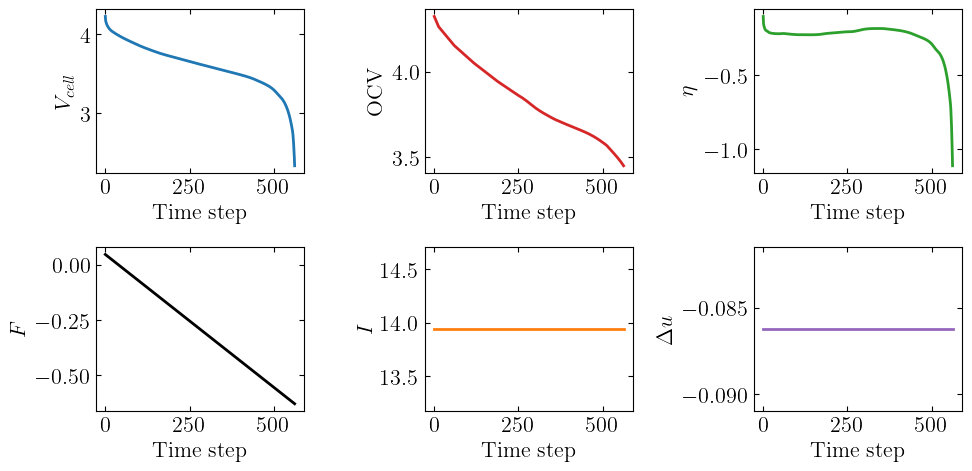

In [ ]:

plot_idx = data['trajectory'] == 0
f, ax = plt.subplots(2, 3, figsize=(10, 5))
ax[0,0].plot(data['V_t'][plot_idx], '-', color = colors[0], lw = 2)
ax[0,0].set_xlabel('Time step')
ax[0,0].set_ylabel('$V_{cell}$')
ax[0,1].plot(data['ocv'][plot_idx], '-', color = colors[1], lw = 2)
ax[0,1].set_xlabel('Time step')
ax[0,1].set_ylabel('OCV')
ax[0,2].plot(data['eta'][plot_idx], '-', color = colors[2], lw = 2)
ax[0,2].set_xlabel('Time step')
ax[0,2].set_ylabel(r'$\eta$')
ax[1,0].plot(data['Rx'][plot_idx], lw = 2,color = colors[3])
ax[1,0].set_xlabel('Time step')
ax[1,0].set_ylabel(r'$F$')
ax[1,1].plot(data['I'][plot_idx], lw = 2,color = colors[4])
ax[1,1].set_xlabel('Time step')
ax[1,1].set_ylabel(r'$I$')
ax[1,2].plot(data['u'][plot_idx], lw = 2,color = colors[5])
ax[1,2].set_xlabel('Time step')
ax[1,2].set_ylabel(r'$\Delta u$')
#ax[].plot(data['ocv'][plot_idx], lw = 2,color = colors[4])

plt.tight_layout()
plt.show()

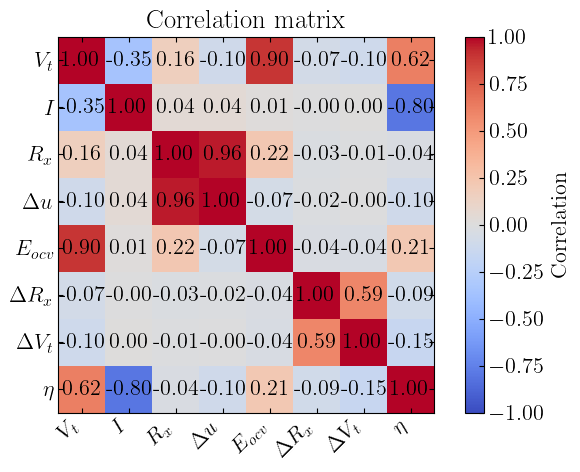

In [ ]:
# Correlation matrix for current signals in this batch

X = data[['V_t','I','Rx','u_par','ocv','dRx','dV_t','eta']].values
feature_names = ['$V_t$','$I$','$R_x$',r'$\Delta u$','$E_{ocv}$',r'$\Delta R_x$',r'$\Delta V_t$',r'$\eta$']
with np.errstate(invalid="ignore", divide="ignore"):
    corr = np.corrcoef(X, rowvar=False)


fig, ax_corr = plt.subplots(figsize=(7, 5))
im = ax_corr.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax_corr.set_xticks(np.arange(len(feature_names)))
ax_corr.set_yticks(np.arange(len(feature_names)))
ax_corr.set_xticklabels(feature_names, rotation=45, ha="right")
ax_corr.set_yticklabels(feature_names)
ax_corr.set_title("Correlation matrix")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax_corr.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", color="black")

fig.colorbar(im, ax=ax_corr, label="Correlation")
plt.tight_layout()
plt.show()

53.164 GN/mm


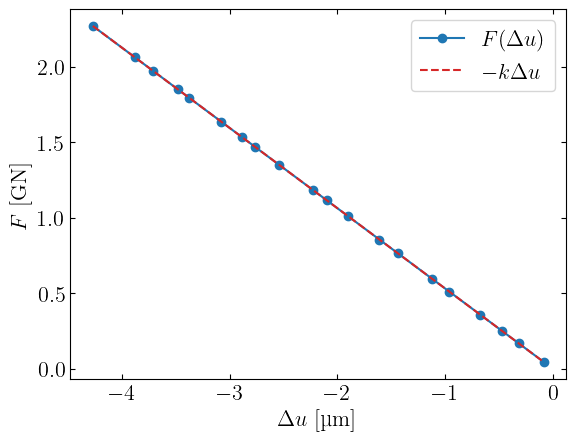

In [ ]:
traj = 0
#plt.plot(data['u'][data['trajectory'] == traj], data['Rx'][data['trajectory'] == traj], lw = 2, color = colors[0])
groups = data.groupby('u')['Rx']


first_rx = data.groupby('u')['Rx'].first()
k = abs(first_rx / (data.groupby('u')['u'].first()))
plt.plot(data.groupby('u')['u'].first(), first_rx, 'o-', color = colors[0], label = r'$F(\Delta u)$')
plt.plot(data.groupby('u')['u'].first(), -k * data.groupby('u')['u'].first(), '--', color = colors[1], label = r'$-k\Delta u$')
plt.xlabel(r'$\Delta u$ [µm]')
plt.ylabel(r'$F$ [GN]')
plt.legend()
print(f'{100 * k.values[0]:.3f} GN/mm')


Text(0, 0.5, '$F$ [MN]')

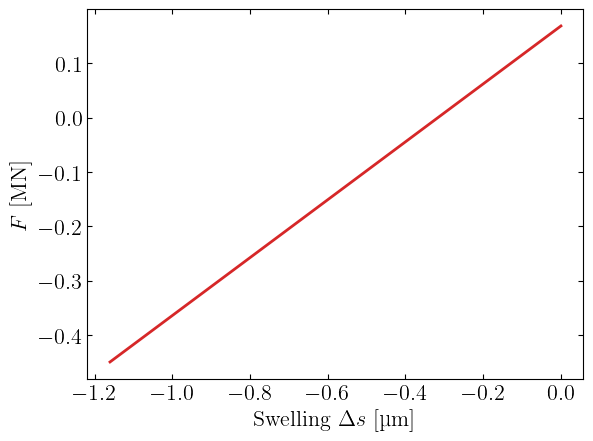

In [ ]:
traj = 1

ds = data['Rx'][data['trajectory'] == traj] / k.values[0] + data['u'][data['trajectory'] == traj] 

plt.plot(ds,data['Rx'][data['trajectory'] == traj], lw = 2, color = colors[1])
plt.xlabel(r'Swelling $\Delta s$ [µm]')
plt.ylabel(r'$F$ [MN]')

Text(0, 0.5, 'OCV [V]')

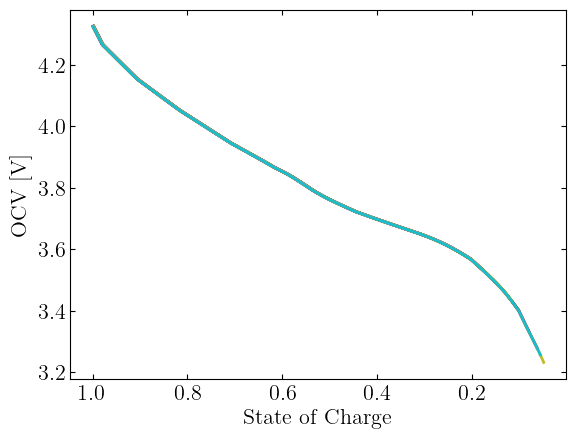

In [ ]:

def SOC(Z_init, I, Q = Q0, dt = DT):
    return Z_init - I * dt / Q

for traj in data['trajectory'].unique():    
    soc = np.ones(len(data['I'][data['trajectory'] == traj]) + 1) * 1.0
    for i in 1 + np.arange(len(data['I'][data['trajectory'] == traj])):
        soc[i] = SOC(soc[i-1], data['I'][data['trajectory'] == traj].iloc[i-1])
    data.loc[data['trajectory'] == traj, 'soc'] = soc[1:]

    plt.plot(soc[1:],data['ocv'][data['trajectory'] == traj], lw = 2, label = f'I = {(data['I'][data['trajectory'] == traj].values)[0]} ')
plt.xlabel('State of Charge')
plt.gca().invert_xaxis()
plt.ylabel('OCV [V]')

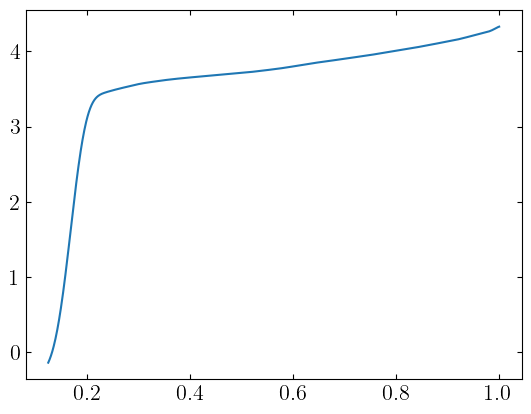

In [ ]:
import sklearn.gaussian_process as gp
from scipy import stats
def GP_process(alpha, X,y,X_test):
    kernel_GP = gp.kernels.RBF(length_scale=alpha[0]) * gp.kernels.ConstantKernel(constant_value=alpha[1])
    gp_model = gp.GaussianProcessRegressor(kernel=kernel_GP,optimizer=None,normalize_y=False)

    gp_model.fit(X, y)

    gp_mu, gp_cov = gp_model.predict(X_test, return_cov=True)

    return gp_mu, gp_cov, gp_model


def gen_samples(y, x):
    sig = 0.01
    l = 0.05
    alpha = [l, sig]


    x_0 = np.linspace(0, 1, 1000)
    
    mu, cov, gp_model = GP_process(alpha, x.reshape(-1,1), y.reshape(-1,1), x_0.reshape(-1,1))
    sample = stats.multivariate_normal.rvs(mean=mu, cov=cov)
    #sample = sample * 3600 / I_int

    return sample

plt.plot(np.linspace(data['soc'][data['trajectory'] == 0].values.min(),1,1000), gen_samples(data['ocv'][data['trajectory'] == 0].values,data['soc'][data['trajectory'] == 0].values))

# Normalizing data

### Characteristics that should be preserved after normalization?


- $\Delta u$: It should primarily be compression, so have a negative sign. 
    - $\Delta u / L$ gives a fractional compression 
- $I$: The sign of it should reflect if we have charge/discharge
    - Maybe just a `standard` normalization on this? 
- $V$: It should always be positive
    - Maybe just a `min-max` normalization on this? 
- $F$: The sign of it should in some way reflect the sign of $\Delta u$. Especially in the cases with low swelling. 
    - Maybe just a `standard` normalization on this? 

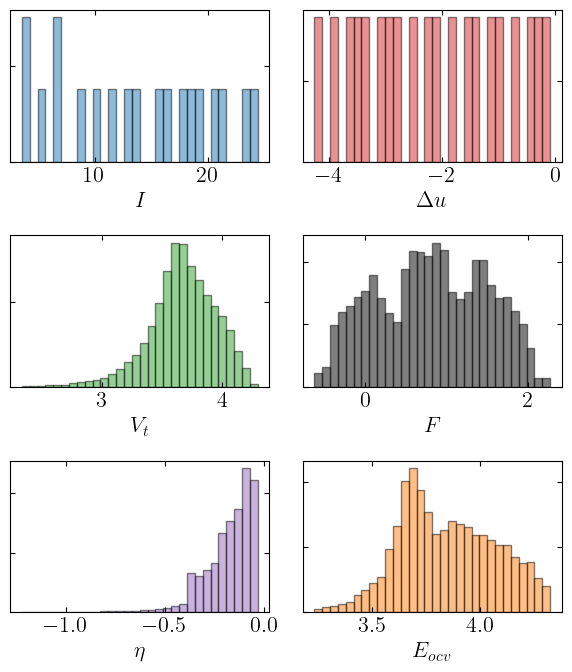

In [ ]:
f, ax = plt.subplots(3,2,figsize=(6, 7))
ax[0,0].hist(np.unique(data['I']), bins=30, color=colors[0], alpha=0.5,edgecolor='black',density=True)
ax[0,1].hist(np.unique(data['u']) , bins=30, color=colors[1], alpha=0.5,edgecolor='black',density=True)
ax[1,0].hist(data['V_t'], bins=30, color=colors[2], alpha=0.5,edgecolor='black',density=True)
ax[1,1].hist(np.unique(data['Rx']), bins=30, color=colors[3], alpha=0.5,edgecolor='black',density=True)
ax[2,1].hist(data['ocv'], bins=30, color=colors[4], alpha=0.5,edgecolor='black',density=True)
ax[2,0].hist((data['eta']), bins=30, color=colors[5], alpha=0.5,edgecolor='black',density=True)
ax[0,0].set_xlabel('$I$')
ax[0,1].set_xlabel(r'$\Delta u$')
ax[1,0].set_xlabel('$V_t$')
ax[1,1].set_xlabel('$F$')
ax[2,1].set_xlabel('$E_{ocv}$')
ax[2,0].set_xlabel(r'$\eta$')
#ax[2,0].set_xlabel('$E_{ocv}$')
#ax[2,1].set_xlabel('$d$')
for a in ax.flat:
    a.set_yticklabels([])
plt.tight_layout()
plt.show()

In [ ]:
N_trajs = len(data['trajectory'].unique())


# test_inds = data['trajectory'] >= int(N_trajs * 0.8)

# print(test_inds.sum(), 'test samples')

# X = np.zeros((len(data) +1, 3))
# y = np.zeros((len(data) + 1,2))
# print(len(data[['V_t']].values))
# traj_len0 = 0

# for traj_ids in range(0, N_trajs):
#     traj_len1 = traj_len0 + len(data[data['trajectory'] == traj_ids]) - 1
#     X[traj_len0:traj_len1,...] = data[['I','u', 'ocv']][data['trajectory'] == traj_ids].values[:]
#     y[traj_len0:traj_len1,...] = data[['V_t','Rx']][data['trajectory'] == traj_ids].values[:]

#     traj_len0 = traj_len1



X = data[['I','u', 'ocv','trajectory']].values
y = data[['V_t','Rx','trajectory']].values

In [ ]:
x_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

split = (data['trajectory']<=int(N_trajs *0.8)).sum()

def _split_flat(arr, split = split):
    return arr[:split], arr[split:]   # Same as reshape(B * T, C)    # (B*T, 4)

x_train, x_test = _split_flat(x_tensor); y_train, y_test = _split_flat(y_tensor)

print(f'Number of trajectories in train: {int(N_trajs * 0.8)} out of {N_trajs}')

print(f'X shape {x_tensor.shape}\ty shape {y_tensor.shape}\nX-train shape: {x_train.shape}\ty-train shape: {y_train.shape}\nX-test shape: {x_test.shape}\ty-test shape: {y_test.shape}')

display(x_train[:5], y_train[:5])

#df_train = data[data['trajectory'] <= int(N_trajs * 0.8)]
#df_test = data[data['trajectory'] > int(N_trajs * 0.8)]

#train_loader_flat = DataLoader(TensorDataset(x_train, y_train), shuffle=False)

Number of trajectories in train: 16 out of 20
X shape torch.Size([15406, 4])	y shape torch.Size([15406, 3])
X-train shape: torch.Size([13069, 4])	y-train shape: torch.Size([13069, 3])
X-test shape: torch.Size([2337, 4])	y-test shape: torch.Size([2337, 3])


tensor([[13.9390, -0.0862,  4.3250,  0.0000],
        [13.9390, -0.0862,  4.3203,  0.0000],
        [13.9390, -0.0862,  4.3155,  0.0000],
        [13.9390, -0.0862,  4.3108,  0.0000],
        [13.9390, -0.0862,  4.3061,  0.0000]])

tensor([[4.2193, 0.0458, 0.0000],
        [4.1657, 0.0447, 0.0000],
        [4.1479, 0.0435, 0.0000],
        [4.1338, 0.0423, 0.0000],
        [4.1221, 0.0411, 0.0000]])

In [ ]:
''' Mk 1 '''


# def ECM_box(Ue, I, R0):
#     Ue = denormalize(Ue, 'ocv')
#     I = denormalize(I, 'I')
#     return normalize(Ue - I * R0, 'V_t')

# def Mech_box(u,s , k = k.values[0]):
#     u = denormalize(u, 'u')
#     s = denormalize(s, 'u')
#     return normalize(-k * u + k * s, 'Rx')

def ECM_box(Ue, I, R0):
    return Ue - I * R0

def Mech_box(u,Fs , k = k.values[0]):
    return -k * u + Fs

def force_func(soc):
    return 1 - np.exp(50*(soc - 1))



In [ ]:
import torch.nn.functional as TF

class Net(nn.Module):
    def __init__(self, input_size=3, hidden_size=256): 
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 2)   # output size is 2 for (V_cell, F)
        )

    def forward(self, x):
        R0_raw, Fs_raw = self.net(x)[:,0], self.net(x)[:,1]
        R0 = TF.softplus(R0_raw)  # Ensure R0 is non-negative
        Fs = Fs_raw#-TF.softplus(-Fs_raw)  # Ensure Fs is non-positive
        return R0, Fs


model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)  

In [ ]:
try: 
    print(summary(model, input_data=x_train[:2]))
except Exception as e:
    print(f"Error in model summary: {e}")

Error in model summary: Failed to run torchinfo. See above stack traces for more details. Executed layers up to: []


In [ ]:
# def next_step(x, Ue, I, k, u):
#     R0_dot, F_dot = model(x)
#     R0 = R0_dot * dt + x[:,0]
#     F  = F_dot  * dt + x[:,1] 

#     Vt = ECM_box(Ue,I,R0)
#     FR = Mech_box(u,k,F)

#     return torch.stack([R0, F], dim=1), Vt, FR



def training(epochs=30):
    history = {"loss": [], "d_loss": [], "p_loss": [], "time per ep": []}

    model.train()
    for ep in range(epochs):
        start_t = time.perf_counter()    
        ep_loss = 0.0
        tot_time = 0.

        for traj in range(int(N_trajs * 0.8)):

            x_traj = x_train[x_train[:, -1] == traj]
            y_traj = y_train[y_train[:, -1] == traj]

            # Inputs
            model_input = x_traj[:, :-1]      # (T, 3)
            model_target = y_traj[:,:-1]     # (T, 2)

            I   = model_input[:, 0]
            u   = model_input[:, 1]
            Ue  = model_input[:, 2]
            soc = model_input[:,3]

            # Forward
            R0, Fs_raw = model(model_input)     # (T,), (T,)
            Fs = force_func(soc) * Fs_raw
            y_pred = torch.stack([
                ECM_box(Ue, I, R0),
                Mech_box(u, Fs)
            ], dim=1)                       # (T, 2)

            loss = nn.MSELoss()(y_pred, model_target)

            # Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        ep_loss += loss.item()

        ep_loss /= N_trajs

        history["loss"].append(ep_loss)
        end_t = time.perf_counter()
        history["time per ep"].append(end_t - start_t)   
        
        tot_time += end_t - start_t
       
        if ep == 0:
            print(f'ETA: {(end_t - start_t) * epochs / 60:.2f} min')

        if tot_time > 2*60:
            print("Early stopping: Total training time exceeded 3 minutes.")
            break
        print(f"Epoch {ep+1} | loss {ep_loss:.3e} | time {end_t - start_t:.2f}s")

    return history      

In [ ]:
history = training(epochs=500)

ETA: 0.72 min
Epoch 1 | loss 1.239e-01 | time 0.09s
Epoch 2 | loss 2.374e-02 | time 0.07s
Epoch 3 | loss 1.087e-02 | time 0.07s
Epoch 4 | loss 1.230e-02 | time 0.07s
Epoch 5 | loss 7.566e-03 | time 0.07s
Epoch 6 | loss 4.816e-03 | time 0.07s
Epoch 7 | loss 3.859e-03 | time 0.07s
Epoch 8 | loss 4.103e-03 | time 0.07s
Epoch 9 | loss 5.237e-03 | time 0.08s
Epoch 10 | loss 6.737e-03 | time 0.09s
Epoch 11 | loss 8.369e-03 | time 0.08s
Epoch 12 | loss 9.508e-03 | time 0.07s
Epoch 13 | loss 9.835e-03 | time 0.07s
Epoch 14 | loss 9.309e-03 | time 0.07s
Epoch 15 | loss 8.249e-03 | time 0.07s
Epoch 16 | loss 7.025e-03 | time 0.07s
Epoch 17 | loss 5.795e-03 | time 0.07s
Epoch 18 | loss 5.056e-03 | time 0.06s
Epoch 19 | loss 4.251e-03 | time 0.07s
Epoch 20 | loss 3.978e-03 | time 0.07s
Epoch 21 | loss 3.910e-03 | time 0.07s
Epoch 22 | loss 3.973e-03 | time 0.06s
Epoch 23 | loss 4.067e-03 | time 0.07s
Epoch 24 | loss 4.213e-03 | time 0.06s
Epoch 25 | loss 4.342e-03 | time 0.07s
Epoch 26 | loss 4.38

[]


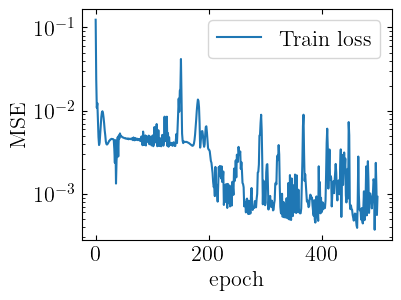

In [ ]:
print(history['d_loss'])
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 3))
ax1.semilogy(history["loss"], label="Train loss")
# ax1.set_yscale("log")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MSE")
ax1.legend()

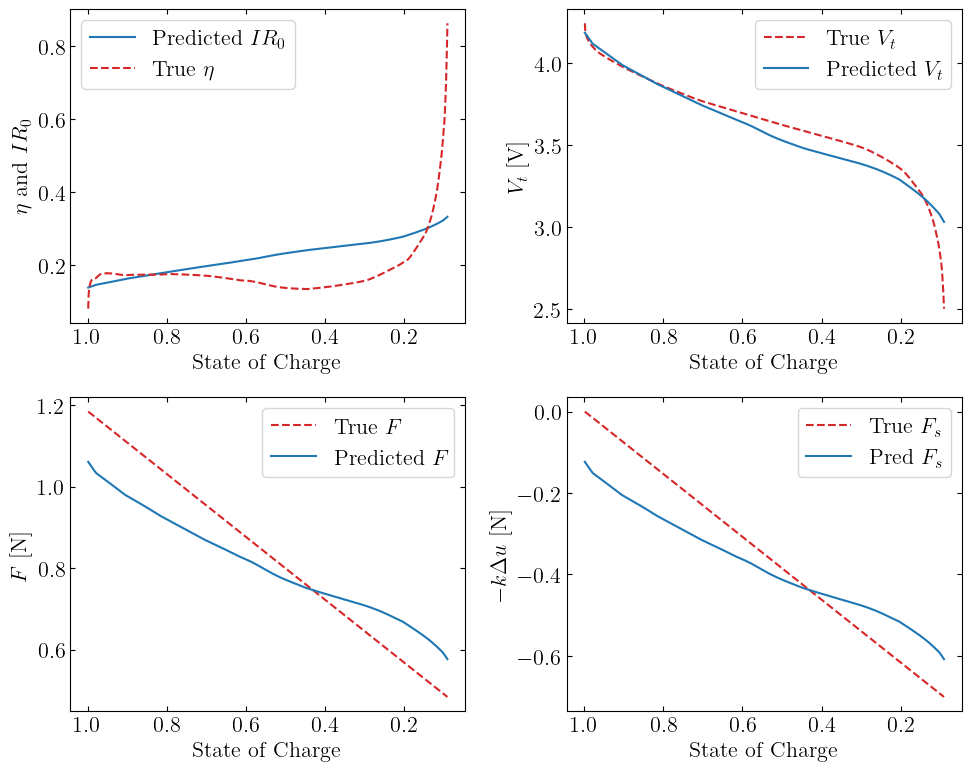

In [ ]:
def evaluate(model, x_test, y_test):
    model.eval()
    with torch.no_grad():
        I = x_test[:,0]
        u = x_test[:,1]
        Ue = x_test[:,2]

        R0_pred, F_pred = model(x_test)
        y_pred = torch.stack([ECM_box(Ue,I,R0_pred), Mech_box(u,F_pred)],dim=1)

        #test_loss = nn.MSELoss()(y_pred, y_test).item()
    #print(f"Test MSE: {test_loss:.3e}")
    return y_pred.detach().numpy(), R0_pred.detach().numpy(), F_pred.detach().numpy()   


traj_eval = 4
y_pred, R0, F = evaluate(model, x_train[x_train[:,3] == traj_eval][:,:-1], y_train[y_train[:,2] == traj_eval][:,:-1])


f, ax = plt.subplots(2, 2, figsize=(10, 8))
#plt.plot(x_test[:,0].numpy()* R0.detach().numpy(), label='Predicted $R_0$')
ax[0,0].plot(data['soc'][data['trajectory'] == traj_eval].values,x_train[x_train[:,3] == traj_eval][:,0].numpy()* R0, label=r'Predicted $IR_0$',color = colors[0])
ax[0,0].plot(data['soc'][data['trajectory'] == traj_eval].values,-data['eta'][data['trajectory'] == traj_eval].values, label=r'True $\eta$',color = colors[1],ls = '--')

ax[0,1].plot(data['soc'][data['trajectory'] == traj_eval].values,data['V_t'][data['trajectory'] == traj_eval].values, label=r'True $V_t$', color = colors[1],ls = '--')
ax[0,1].plot(data['soc'][data['trajectory'] == traj_eval].values,y_pred[:,0], label=r'Predicted $V_t$', color = colors[0])

ax[1,0].plot(data['soc'][data['trajectory'] == traj_eval].values,data['Rx'][data['trajectory'] == traj_eval].values, label=r'True $F$', color = colors[1],ls = '--')
ax[1,0].plot(data['soc'][data['trajectory'] == traj_eval].values,y_pred[:,1], label=r'Predicted $F$', color = colors[0])    

ax[1,1].plot(data['soc'][data['trajectory'] == traj_eval].values,data['Rx'][data['trajectory'] == traj_eval].values + k.values[0] * x_train[x_train[:,3] == traj_eval][:,1].numpy(), label=r'True $F_s$', color = colors[1], ls = '--')
ax[1,1].plot(data['soc'][data['trajectory'] == traj_eval].values,F, label=r'Pred $F_s$', color = colors[0])

for a in ax.flat:
    a.set_xlabel('State of Charge')
    a.legend()
    a.invert_xaxis()
ax[0,0].set_ylabel(r'$\eta$ and $IR_0$')
ax[0,1].set_ylabel(r'$V_t$ [V]')
ax[1,0].set_ylabel(r'$F$ [N]')
ax[1,1].set_ylabel(r'$-k\Delta u$ [N]')
plt.tight_layout()



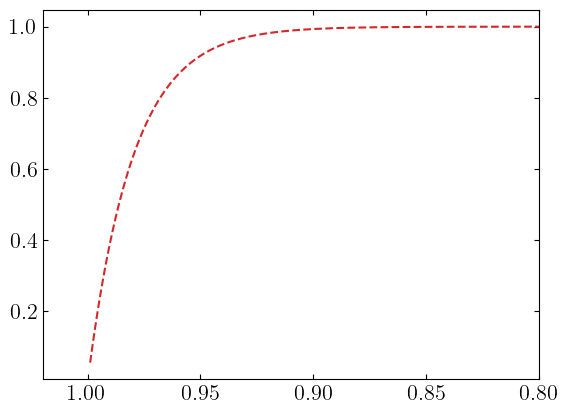

In [ ]:

plt.plot(data['soc'][data['trajectory'] == traj_eval].values, force_func(data['soc'][data['trajectory'] == traj_eval].values), label=r'True $F$', color = colors[1],ls = '--')
plt.xlim(0.8, 1.02)
plt.gca().invert_xaxis()    